# Regional Styles and Patch Evolution in Professional League of Legends (2014–2025)


## 1. Introduction


### Background

Over the past two decades, esports has grown from a niche subculture into a global industry. Among all titles, _League Of Legends_ (LOL) stands out as a defining phenomenon — its annual World Championship now rivals traditional sports finals in viewership. The game also holds a special place in Chinese internet culture: the world titles won by IG (2018, S8), FPX (2019, S9), and EDG (2021, S11) each triggered nationwide celebrations and pushed LoL esports firmly into the mainstream.

Behind the spectacle, professional LoL is also a rich source of structured match data. Every game produces hundreds of measurements — gold, vision, objectives, timing snapshots — across five players per side. This makes it a natural setting for statistical analysis: regional playstyles, meta shifts driven by patches, and the long-term evolution of competitive tempo are all empirically observable rather than merely anecdotal.


### Research Questions

This report focuses on two related questions:

1. **Regional styles.** Do major regions (LPL, LCK, LCS, LEC, and others) display statistically distinguishable playstyles in terms of aggression, early-game economy, vision control, and objective priority?
2. **Patch dynamics.** How have successive game patches reshaped match tempo over 2014–2025, and have they widened or narrowed the stylistic gap between regions?


### Data Source & Scope

All analyses are based on the publicly available **Oracle's Elixir** match dataset, covering professional LoL matches from **2014 through 2025** (twelve full competitive seasons, roughly 1.11 million player-game rows). The 2026 season is excluded because the data is still incomplete at the time of writing.


## 2. Data Overview


### Preparations


In [1]:
"""Global imports for the entire report.

All code cells throughout the notebook rely on the packages imported here,
so this cell should be run first after kernel restart.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats
import seaborn as sns
from sklearn import decomposition, preprocessing
from tqdm.auto import tqdm

from utils.completness import first_usable_year, missing_rate_by_year
from utils.data_loader import load_all_seasons
from utils.preprocess import (
    filter_complete,
    get_player_rows,
    get_team_rows,
    standard_clean,
    require_snapshots,
)
from utils.regions import REGION_ORDER, add_region
from utils.mertics import aggression

# Display & plotting defaults
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Project paths
DATA_DIR = Path("data")
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

### Dataset Structure & Key Fields


In [2]:
df = load_all_seasons()
print(f"Total rows:   {len(df):,}")
print(f"Total cols:   {df.shape[1]}")
print(f"Years:        {sorted(df['year'].unique())}")
print(f"Memory:       {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Total rows:   1,118,796
Total cols:   165
Years:        [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Memory:       1725.8 MB


,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,participantid,side,position,playername,playerid,teamname,teamid,firstPick,champion,ban1,ban2,ban3,ban4,ban5,pick1,pick2,pick3,pick4,pick5,gamelength,result,kills,deaths,assists,teamkills,teamdeaths,doublekills,triplekills,quadrakills,pentakills,...,opp_csat15,golddiffat15,xpdiffat15,csdiffat15,killsat15,assistsat15,deathsat15,opp_killsat15,opp_assistsat15,opp_deathsat15,goldat20,xpat20,csat20,opp_goldat20,opp_xpat20,opp_csat20,golddiffat20,xpdiffat20,csdiffat20,killsat20,assistsat20,deathsat20,opp_killsat20,opp_assistsat20,opp_deathsat20,goldat25,xpat25,csat25,opp_goldat25,opp_xpat25,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,1,Blue,top,sOAZ,oe:player:e4e943fa882367a96fb2a365de4e28c,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Trundle,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,3,0,13,21,5,0.0,0.0,0.0,0.0,...,111.0,49.0,-560.0,-1.0,2.0,0.0,0.0,1.0,1.0,1.0,6958.0,9467.0,166.0,6572.0,10098.0,157.0,386.0,-631.0,9.0,3.0,0.0,0.0,1.0,2.0,1.0,8735.0,12111.0,188.0,8659.0,12623.0,206.0,76.0,-512.0,-18.0,3.0,4.0,0.0,1.0,2.0,2.0
1,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,2,Blue,jng,Cyanide,oe:player:e4cd1e7b68ee6b595a6e4c7cd2c56d8,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Vi,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,0,4,14,21,5,0.0,0.0,0.0,0.0,...,95.0,-1107.0,-703.0,-36.0,0.0,2.0,2.0,2.0,0.0,0.0,5300.0,8598.0,85.0,6504.0,8885.0,115.0,-1204.0,-287.0,-30.0,0.0,3.0,3.0,2.0,1.0,0.0,7122.0,11230.0,98.0,8010.0,10879.0,140.0,-888.0,351.0,-42.0,0.0,5.0,3.0,2.0,1.0,1.0
2,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,3,Blue,mid,xPeke,oe:player:5d69aabb447fa09188638716fe549b6,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Orianna,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,10,1,7,21,5,4.0,1.0,0.0,0.0,...,126.0,-145.0,-148.0,7.0,0.0,1.0,1.0,0.0,2.0,0.0,6740.0,10454.0,194.0,6858.0,10220.0,178.0,-118.0,234.0,16.0,0.0,2.0,1.0,1.0,2.0,0.0,9312.0,13117.0,233.0,8691.0,12384.0,225.0,621.0,733.0,8.0,1.0,5.0,1.0,1.0,2.0,0.0
3,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,4,Blue,bot,Rekkles,oe:player:d8362fe0d38ca0e70953ed957deaa00,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Jinx,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,8,0,9,21,5,2.0,1.0,0.0,0.0,...,103.0,1588.0,998.0,22.0,3.0,0.0,0.0,0.0,0.0,3.0,7537.0,7884.0,181.0,5637.0,7246.0,143.0,1900.0,638.0,38.0,3.0,1.0,0.0,0.0,0.0,3.0,10279.0,11126.0,211.0,7014.0,9176.0,161.0,3265.0,1950.0,50.0,6.0,2.0,0.0,0.0,0.0,4.0
4,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,5,Blue,sup,YellOwStaR,oe:player:5ebcf3b41dc66e5839da4c5f58bd907,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Annie,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,0,0,15,21,5,0.0,0.0,0.0,0.0,...,23.0,887.0,476.0,-15.0,0.0,4.0,0.0,0.0,0.0,1.0,4524.0,6100.0,8.0,3452.0,5229.0,24.0,1072.0,871.0,-16.0,0.0,4.0,0.0,0.0,1.0,2.0,6277.0,8865.0,9.0,4497.0,6468.0,28.0,1780.0,2397.0,-19.0,0.0,7.0,0.0,0.0,1.0,3.0


### Data Completeness Across Years

Early years caveat.


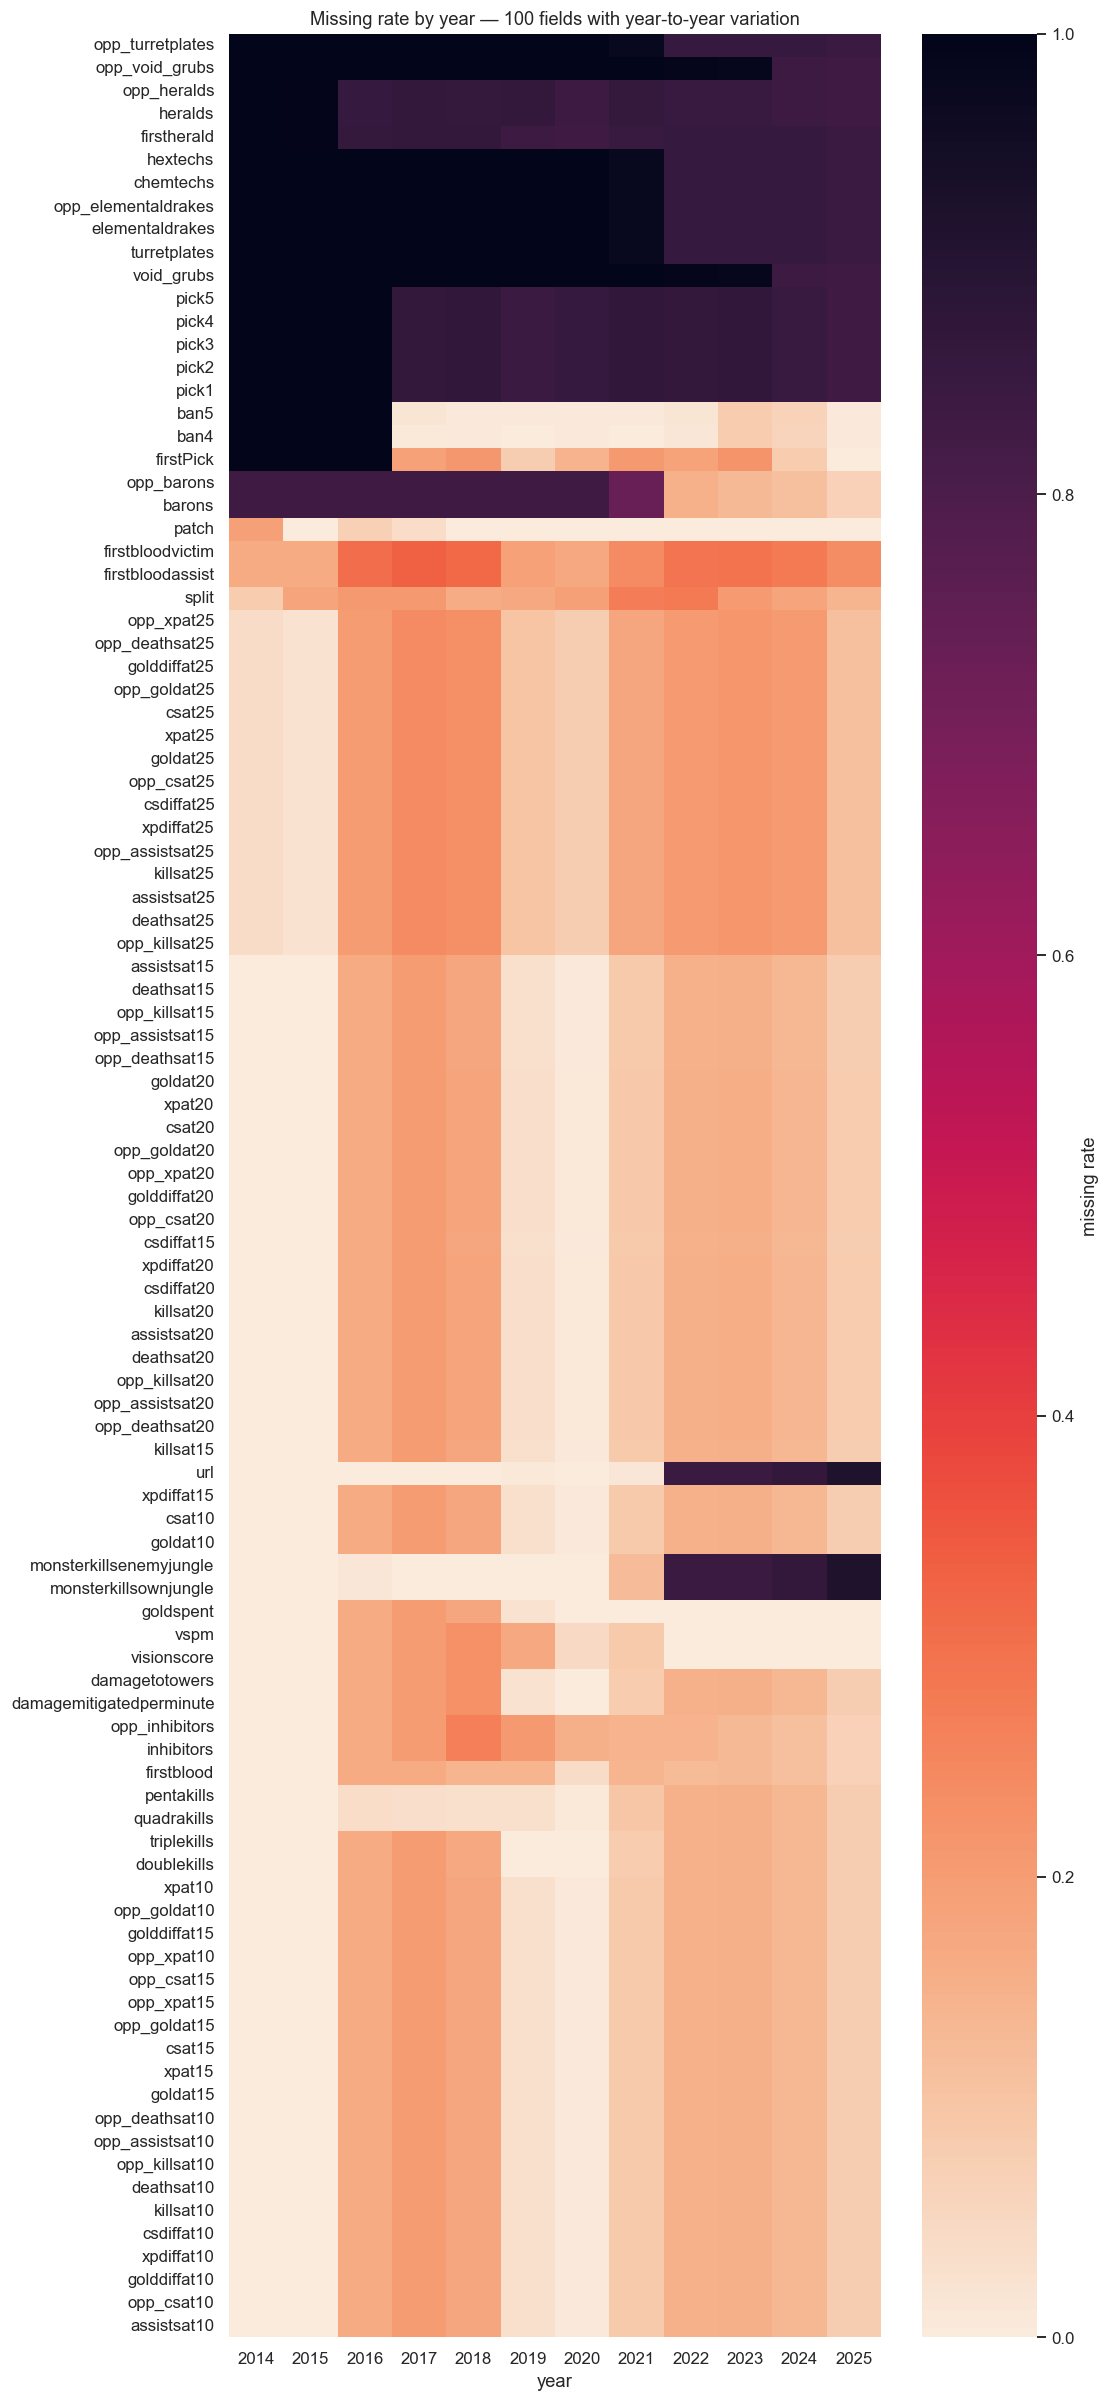

,first_usable_year
gameid,2014
opp_killsat15,2014
deathsat15,2014
assistsat15,2014
killsat15,2014
...,...
ban4,2017
ban5,2017
firstPick,2019
opp_barons,2025


In [3]:
miss = missing_rate_by_year(df=df)

varying = miss.columns[miss.std() > 0.05]
heat = miss[varying].T.sort_values(2014, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(varying) * 0.22)))
sns.heatmap(heat, cmap="rocket_r", vmin=0, vmax=1, cbar_kws={"label": "missing rate"}, ax=ax)
ax.set_title(f"Missing rate by year — {len(varying)} fields with year-to-year variation")
plt.tight_layout()
plt.show()

first_usable_year(miss).dropna().sort_values().to_frame()

We find that, our dataset covers 119 competitions or leagues. Major region (LPL / LCK / LCS / LEC) sums up to 17000 games, which take parts of 15% of all games. The rests are subleagues or academy games. In our chapter 5, we only uses main region, and take others in to account if needed. International of subleagues will be processed singly or give out.


### Regions Included & Sample Sizes


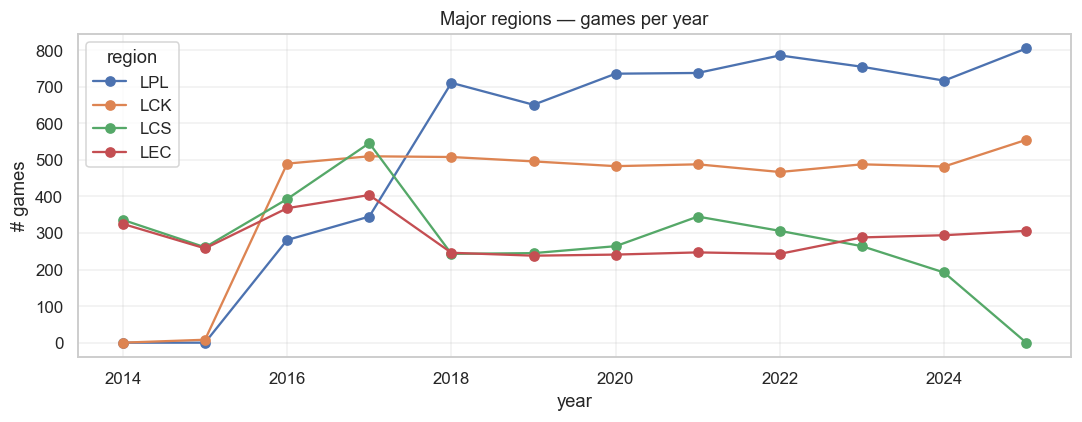

In [4]:
df = add_region(df)

# Competitions of each region
region_year = (
    df.drop_duplicates("gameid")
    .groupby(["region", "year"])
    .size()
    .unstack(fill_value=0)
    .reindex(REGION_ORDER)
)

# Visualize
main = region_year.loc[["LPL", "LCK", "LCS", "LEC"]]
fig, ax = plt.subplots(figsize=(10, 4))
main.T.plot(ax=ax, marker="o")
ax.set_title("Major regions — games per year")
ax.set_ylabel("# games")
ax.legend(title="region")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Preprocessing Decisions

e.g., excluding incomplete rows, separating team rows vs. player rows.


In [5]:
# check data structure
print("=== Row structure ===")
print(f"Total rows:        {len(df):,}")
print(
    f"Player rows:       {len(get_player_rows(df)):,}  ({len(get_player_rows(df)) / len(df):.1%})"
)
print(f"Team rows:         {len(get_team_rows(df)):,}  ({len(get_team_rows(df)) / len(df):.1%})")
print(f"Unique games:      {df['gameid'].nunique():,}")

# Filter the effects of decision
print("=== Filtering impact (on game count) ===")
n_total = df["gameid"].nunique()
n_complete = filter_complete(df)["gameid"].nunique()
n_clean = standard_clean(df)["gameid"].nunique()
print(f"All games:                       {n_total:,}")
print(f"... after datacompleteness only: {n_complete:,}  (-{n_total - n_complete:,})")
print(f"... after standard_clean:        {n_clean:,}  (-{n_total - n_clean:,})")


=== Row structure ===
Total rows:        1,118,796
Player rows:       932,330  (83.3%)
Team rows:         186,466  (16.7%)
Unique games:      93,233
=== Filtering impact (on game count) ===
All games:                       93,233
... after datacompleteness only: 82,511  (-10,722)
... after standard_clean:        93,227  (-6)


Rules of preprocessing:

- Players (KDA, CSPM, Vision Scores, etc): `get_player_rows()`, 12 rows/game
- Games (Winner, Dragon/Baron, golddiff, etc): `get_team_rows()`, 2 rows/game

1. `datacompleteness == 'complete'`: filter some missing data.
2. `gamelength >= 900s`: filter remake/surrender.


## 3. The Evolution of the Game (Macro Trends, 2014–2025)


Using data processor, we fetch and process to get cleaned data.


In [6]:
games = (
    standard_clean(df)
    .pipe(get_team_rows)
    .pipe(add_region)
    .drop_duplicates("gameid")
    .assign(gamelength_min=lambda d: d["gamelength"] / 60)
)
print(f"Games after standard_clean: {len(games):,}")

Games after standard_clean: 93,227


### Match Duration Over the Years


First, let's see how game duration change over the years.


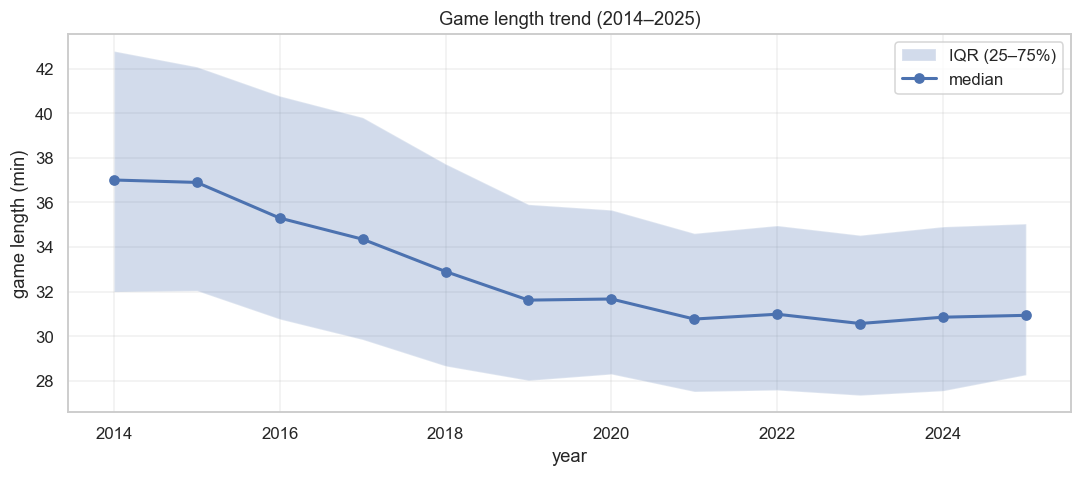

In [7]:
yearly = games.groupby("year")["gamelength_min"].agg(
    median="median", q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(yearly.index, yearly["q25"], yearly["q75"], alpha=0.25, label="IQR (25–75%)")
ax.plot(yearly.index, yearly["median"], marker="o", linewidth=2, label="median")
ax.set_title("Game length trend (2014–2025)")
ax.set_ylabel("game length (min)")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


Precisely, let's see game duration of each region.


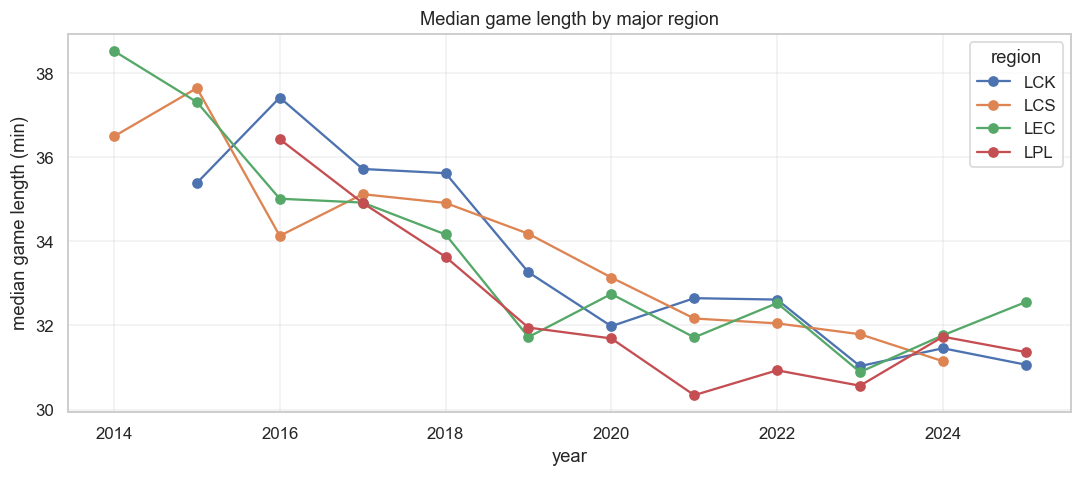

In [8]:
main_regions = ["LPL", "LCK", "LCS", "LEC"]
by_region = (
    games[games["region"].isin(main_regions)]
    .groupby(["year", "region"])["gamelength_min"]
    .median()
    .unstack("region")
)

fig, ax = plt.subplots(figsize=(10, 4.5))
by_region.plot(ax=ax, marker="o")
ax.set_title("Median game length by major region")
ax.set_ylabel("median game length (min)")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
ax.legend(title="region")
plt.tight_layout()
plt.show()

然后看整体分布的 boxplot，看看离群值


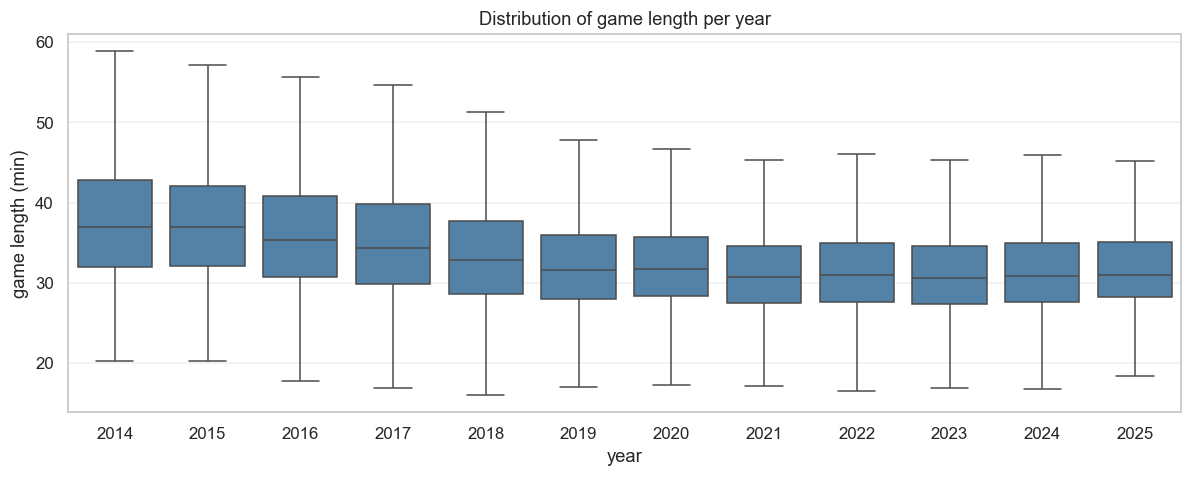

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(
    data=games,
    x="year",
    y="gamelength_min",
    showfliers=False,
    color="steelblue",
    ax=ax,
)
ax.set_title("Distribution of game length per year")
ax.set_ylabel("game length (min)")
ax.set_xlabel("year")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Kill Pace (Kills per Minute) Over the Years


In [10]:
games_kpm: pd.DataFrame = (
    standard_clean(df)
    .pipe(get_team_rows)
    .pipe(add_region)
    .groupby(["gameid", "year", "region", "gamelength"], as_index=False)["kills"]
    .sum()
    .assign(
        gamelength_min=lambda d: d["gamelength"] / 60,
        kpm=lambda d: d["kills"] / (d["gamelength"] / 60),
    )
)

print(f"Games for KPM analysis: {len(games_kpm):,}")
games_kpm[["year", "kills", "gamelength_min", "kpm"]].describe()

Games for KPM analysis: 93,227


,year,kills,gamelength_min,kpm
count,93227.000000,93227.000000,93227.000000,93227.000000
mean,2020.987750,28.397439,32.473182,0.892801
std,2.771123,9.782715,6.316814,0.314750
min,2014.000000,1.000000,15.183333,0.046729
25%,2019.000000,21.000000,28.100000,0.669800
50%,2021.000000,27.000000,31.550000,0.857143
75%,2023.000000,34.000000,35.966667,1.072424
max,2025.000000,109.000000,94.666667,3.854875


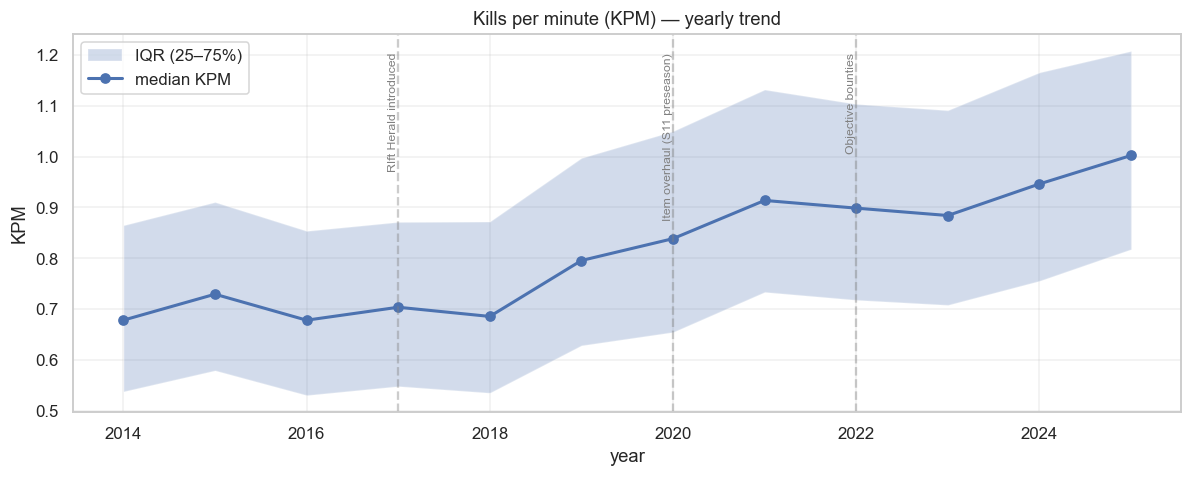

In [11]:
yearly_kpm = games_kpm.groupby("year")["kpm"].agg(
    median="median",
    q25=lambda s: s.quantile(0.25),
    q75=lambda s: s.quantile(0.75),
    mean="mean",
)


fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(
    yearly_kpm.index, yearly_kpm["q25"], yearly_kpm["q75"], alpha=0.25, label="IQR (25–75%)"
)
ax.plot(yearly_kpm.index, yearly_kpm["median"], marker="o", lw=2, label="median KPM")

# Some key time
PATCH_MARKERS = {
    2017: "RIft Herald introduced",
    2020: "Item overhaul (S11 preseason)",
    2022: "Objective bounties",
}
for y, label in PATCH_MARKERS.items():
    ax.axvline(y, color="gray", ls="--", alpha=0.4)
    ax.text(
        y,
        ax.get_ylim()[1] * 0.97,
        label,
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
        color="gray",
    )


ax.set_title("Kills per minute (KPM) — yearly trend")
ax.set_xlabel("year")
ax.set_ylabel("KPM")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Similarly, we consider aggregation shown in different regions.


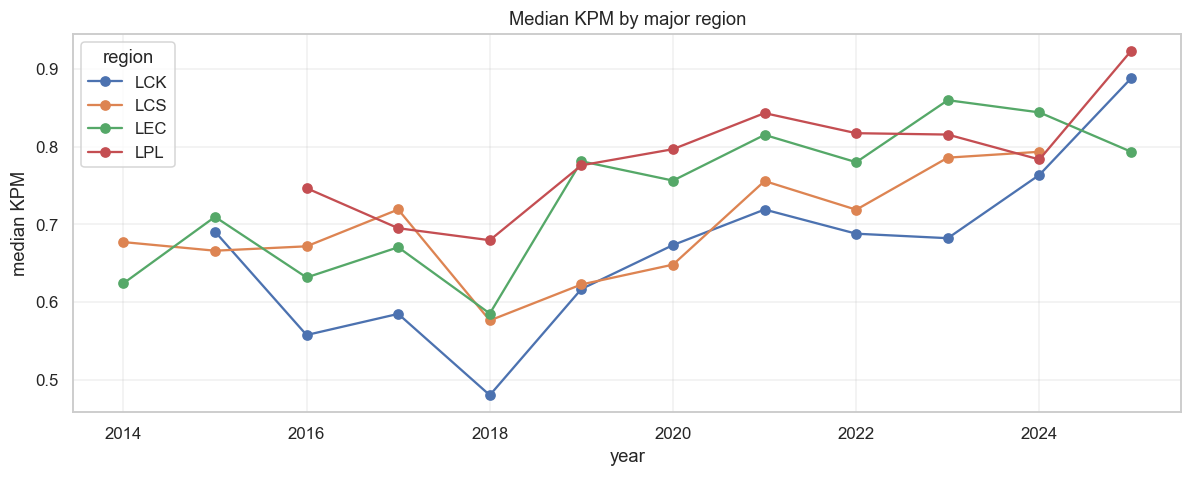

In [12]:
main_regions = ["LPL", "LCK", "LCS", "LEC"]
region_kpm = (
    games_kpm[games_kpm["region"].isin(main_regions)]
    .groupby(["year", "region"])["kpm"]
    .median()
    .unstack("region")
)

fig, ax = plt.subplots(figsize=(11, 4.5))
region_kpm.plot(ax=ax, marker="o")
ax.set_title("Median KPM by major region")
ax.set_xlabel("year")
ax.set_ylabel("median KPM")
ax.grid(alpha=0.3)
ax.legend(title="region")
plt.tight_layout()
plt.show()


### Early-Game vs. Late-Game Resource Distribution Trends


Prepare every year's snapshots.


Public resources also affect game tempo.


In [13]:
snap = standard_clean(df).pipe(require_snapshots).pipe(get_team_rows).pipe(add_region)

snapshot_cols = [
    "goldat10",
    "goldat15",
    "goldat20",
    "goldat25",
    "xpat10",
    "xpat15",
    "xpat20",
    "xpat25",
]

print(f"Games with snapshot data: {snap['gameid'].nunique():,}")
print("\nSnapshot coverage by year:")
print(snap.drop_duplicates("gameid").groupby("year").size())

Games with snapshot data: 82,507

Snapshot coverage by year:
year
2014      918
2015     1815
2016     3515
2017     4399
2018     5433
2019     7653
2020     9615
2021    11123
2022    10641
2023     9372
2024     8802
2025     9221
dtype: int64


Golds


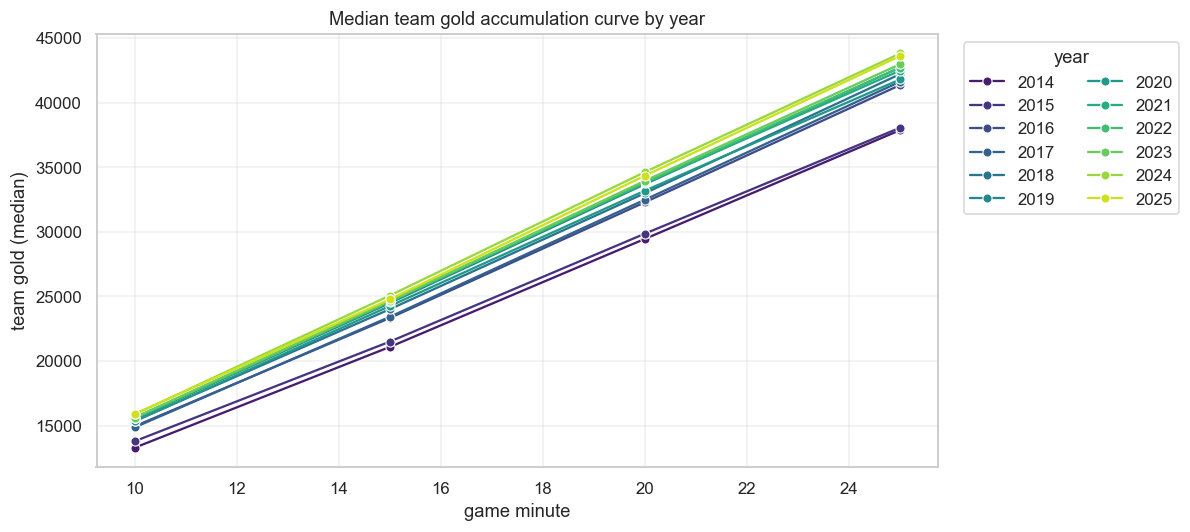

In [14]:
gold_cols = ["goldat10", "goldat15", "goldat20", "goldat25"]
gold_by_year = snap.groupby("year")[gold_cols].median()
gold_long = gold_by_year.reset_index().melt(id_vars="year", var_name="snapshot", value_name="gold")
gold_long["minute"] = gold_long["snapshot"].str.extract(r"(\d+)").astype(int)
gold_long["year"] = gold_long["year"].astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(
    data=gold_long,
    x="minute",
    y="gold",
    hue="year",
    palette="viridis",
    marker="o",
    ax=ax,
)
ax.set_title("Median team gold accumulation curve by year")
ax.set_xlabel("game minute")
ax.set_ylabel("team gold (median)")
ax.grid(alpha=0.3)
ax.legend(title="year", bbox_to_anchor=(1.02, 1), loc="upper left", ncols=2)
plt.tight_layout()
plt.show()


Early proposition.


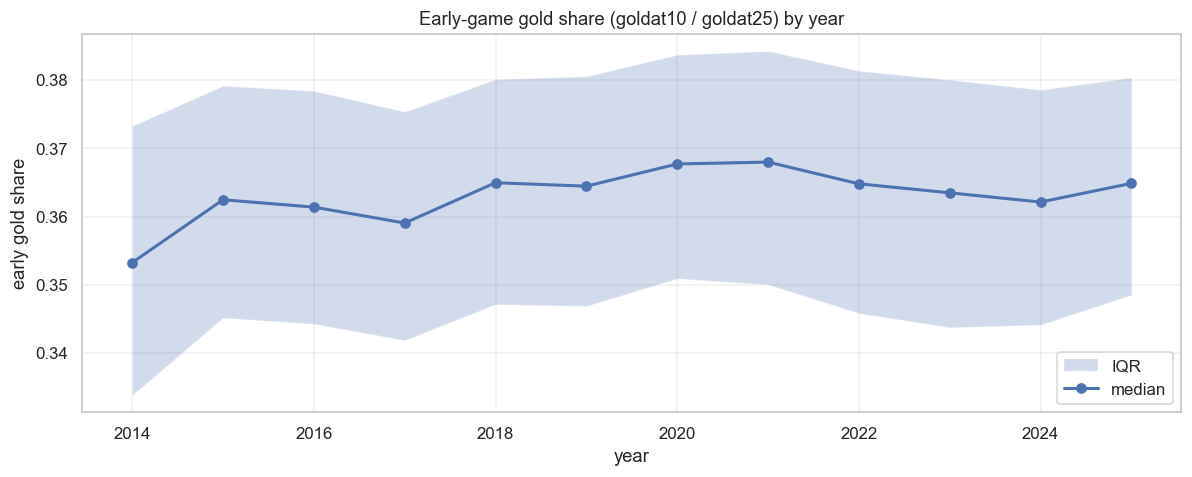

In [15]:
gold_share = (
    snap.assign(early_share=lambda d: d["goldat10"] / d["goldat25"])
    .groupby("year")["early_share"]
    .agg(median="median", q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75))
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(gold_share.index, gold_share["q25"], gold_share["q75"], alpha=0.25, label="IQR")
ax.plot(gold_share.index, gold_share["median"], marker="o", lw=2, label="median")
ax.set_title("Early-game gold share (goldat10 / goldat25) by year")
ax.set_ylabel("early gold share")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


Gold diff


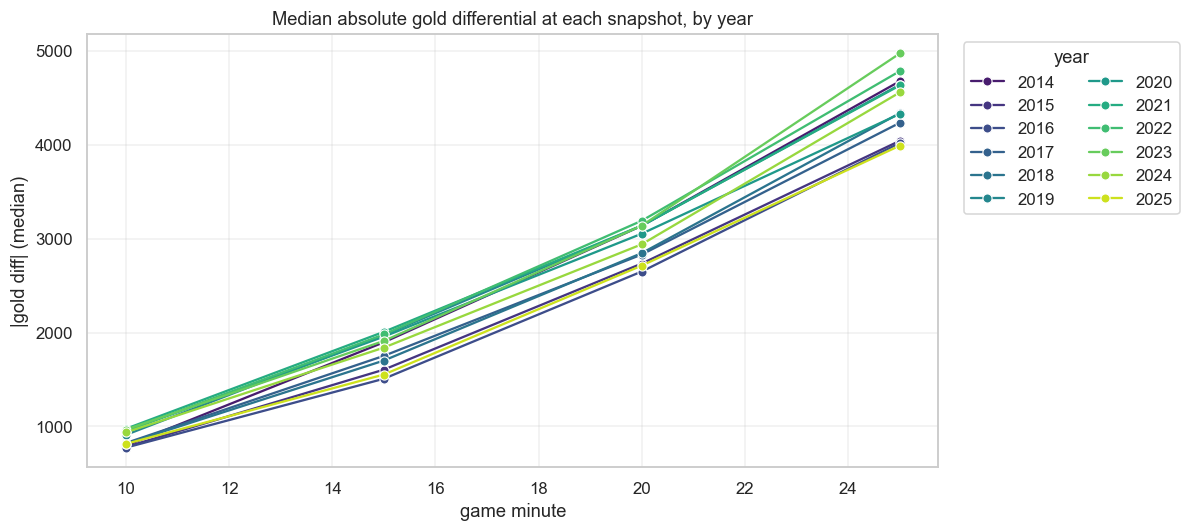

In [16]:
gdiff_cols = ["golddiffat10", "golddiffat15", "golddiffat20", "golddiffat25"]
# golddiffat 对队伍行是有正负的（领先方 +，落后方 -），取绝对值看"差距大小"
gdiff_long = (
    snap[["year"] + gdiff_cols]
    .assign(**{c: snap[c].abs() for c in gdiff_cols})
    .groupby("year")[gdiff_cols]
    .median()
    .reset_index()
    .melt(id_vars="year", var_name="snapshot", value_name="abs_diff")
)
gdiff_long["minute"] = gdiff_long["snapshot"].str.extract(r"(\d+)").astype(int)
gdiff_long["year"] = gdiff_long["year"].astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(
    data=gdiff_long,
    x="minute",
    y="abs_diff",
    hue="year",
    palette="viridis",
    marker="o",
    ax=ax,
)
ax.set_title("Median absolute gold differential at each snapshot, by year")
ax.set_xlabel("game minute")
ax.set_ylabel("|gold diff| (median)")
ax.grid(alpha=0.3)
ax.legend(title="year", bbox_to_anchor=(1.02, 1), loc="upper left", ncols=2)
plt.tight_layout()
plt.show()


### Key Patch Milestones

下表整理 2014–2025 期间对**比赛节奏、目标资源、视野系统、早期博弈**有显著影响的版本节点，作为后续 KPM、游戏时长、视野指标趋势变化的参考时间轴。

| Patch | 大致时间                 | 类别        | 关键改动                                                           | 对比赛的影响                                    |
| ----- | ------------------------ | ----------- | ------------------------------------------------------------------ | ----------------------------------------------- |
| 4.x   | 2014 S4                  | 基线        | 早期赛季，无峡谷先锋 / 大龙魂 / 元素龙增益                         | 节奏慢、运营导向，gamelength 偏长               |
| 5.22  | 2015-11                  | 资源        | **元素龙**（火/水/风/土）取代固定属性龙                            | 龙开始具备战略差异，争夺更频繁                  |
| 6.9   | 2016-04                  | 装备        | **刺客大改**（双瑞文、卡兹克、阿卡丽等）                           | 中野节奏加快，单杀比例上升                      |
| 6.22  | 2016-11 (preseason 7)    | 资源 / 节奏 | **峡谷先锋（Rift Herald）首次引入**；植物系统；视野得分公式调整    | 上路/野区博弈点新增，前期目标增多               |
| 7.22  | 2017-11 (preseason 8)    | 系统        | **符文重铸（Runes Reforged）** 取代旧符文+天赋                     | 出装与对线节奏整体重构                          |
| 8.11  | 2018-05                  | 资源        | 峡谷先锋可在 8 分钟前激活；河蟹改动                                | 早期视野/经济战收益变大                         |
| 9.13  | 2019-07                  | 资源        | **大龙（Baron）增益削弱**，价值后移                                | 大龙不再"一波终结"，比赛时长拉长                |
| 9.23  | 2019-11 (preseason 10)   | 资源        | **大龙魂（Dragon Soul）+ 元素崛起（Elemental Rifts）+ 远古龙**     | 第 4 条龙的战略意义剧增，团战集中后期           |
| 10.23 | 2020-11 (preseason 11)   | 装备        | **神话装备系统**（Mythic Items）大改装备树                         | 多英雄定位重置，出装影响整体节奏                |
| 11.4  | 2021-02                  | 资源        | 化学男爵（Chemtech Drake）首次加入                                 | 龙池扩大，目标博弈更复杂                        |
| 12.5  | 2022-03                  | 资源        | **目标资金（Objective Bounties）**：劣势方击杀大型目标可获额外金钱 | 弱势方追平机会增加，gamelength 偏长且翻盘率提升 |
| 12.14 | 2022-07                  | 资源        | 龙池调整、虚空蛹虫（Void Grubs）测试                               | 上半区野怪博弈细化                              |
| 13.1  | 2023-01                  | 资源        | **虚空蛹虫（Voidgrubs）正式取代峡谷先锋前置**，上半区资源固定化    | 早期上半区博弈节奏更标准化                      |
| 13.10 | 2023-05                  | 装备        | **耐久度补丁（Durability Patch）**：全英雄基础生命/护甲大幅上调    | 单杀难度上升，团战时间延长，KPM 短期下降        |
| 14.1  | 2024-01 (preseason none) | 装备        | **神话装备系统取消**，装备池重构；新增地图植物/野怪改动            | 出装多样性回归，早中期节奏再次调整              |
| 14.10 | 2024-05                  | 资源        | 大龙形态多样化（Baron Variants）                                   | 大龙战略增加变数                                |
| 15.1  | 2025-01                  | 资源        | **新地图大型生物 Atakhan** 加入，野区/大龙窗口调整                 | 团战触发点新增，节奏进一步加快                  |

**引用说明**：本表基于 Riot 官方 Patch Notes，仅列出对宏观比赛指标（KPM、gamelength、视野、目标资源）有可观测影响的版本。具体改动以官方公告为准。


## 4. Defining "Playstyle" — Metrics & Framework

为了系统比较赛区与版本之间的差异，我们将"playstyle"拆解为五个可量化的维度。每个维度由若干来自 Oracle's Elixir 的字段衍生计算，**聚合粒度**统一到 _(team, season)_：每支队伍每年一行，便于后续做赛区均值/分布对比和统计检验。

| 维度                                           | 字段（聚合粒度：team-season）                                              | 计算方式                                                                                                            | 解读                                   |
| ---------------------------------------------- | -------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------- | -------------------------------------- |
| **Aggression**<br>对线/团战进攻性              | `kills`, `gamelength`, `firstblood`, `golddiffat15`                        | • KPM = Σkills / Σgamelength_min<br>• First Blood Rate = mean(firstblood)<br>• 15 分钟金币优势 = mean(golddiffat15) | 数值越高 = 越倾向主动开战 / 早期施压   |
| **Early-Game Dominance**<br>前期建立优势的能力 | `csdiffat10`, `golddiffat10`, `xpdiffat10`                                 | 全部取队伍平均                                                                                                      | 数值越高 = 早期对线/野区建立优势越稳定 |
| **Vision Control**<br>视野与地图信息           | `visionscore`, `wardsplaced`, `wardskilled`, `controlwardsbought`          | 全部取队伍平均（已按选手聚合到队伍）                                                                                | 数值越高 = 视野投入越大 / 信息战越激进 |
| **Objective Focus**<br>地图资源争夺            | `firstdragon`, `dragons`, `firstbaron`, `barons`, `firstherald`, `heralds` | First-X 字段取 mean（= 拿取率），数量字段取 mean                                                                    | 数值越高 = 越优先争夺中立资源          |
| **Macro Tempo**<br>整体节奏                    | `gamelength`, `kpm`（衍生）                                                | gamelength 直接取中位数；KPM 与 Aggression 共用                                                                     | gamelength 越短 / KPM 越高 = 节奏越快  |

### 选取这些指标的理由

1. **覆盖比赛阶段**：early-game dominance 看前 10 分钟，aggression 看 15 分钟前后的冲突倾向，objective focus 看中后期资源争夺，macro tempo 看整体节奏——四个时段各有侧重。
2. **可比性**：所有指标都能按 _(team, season)_ 聚合并对赛区平均，避免单场样本噪声。
3. **数据可用性**：早期年份（2014–2016）部分时间快照字段缺失（参见 §2 Data Completeness），涉及 `*at10/15/20/25` 的维度（Early-Game Dominance, 部分 Aggression）将限定在数据完整的年份范围内分析。
4. **维度间的独立性**：5 个维度虽然有相关性（如 aggression 高的队伍 macro tempo 通常也快），但分别测量不同的行为偏好，组合起来构成"赛区指纹"。

### 聚合粒度说明

- **选手层指标**（视野字段）：先按 (gameid, teamname) 求和或平均，再聚合到 (team, season)
- **队伍层指标**（gold diff, kills, objectives）：直接从 team 行（participantid 100/200）取数
- **不区分胜负**：playstyle 是行为倾向，不应被结果偏置（虽然胜利队伍 KDA 自然更好，但 KPM 反映的是"打得多激进"，与胜负相关性弱）

后续 §4.1–§4.5 分别落地每个维度的具体计算，结果汇总到一张 (team, season, metric) 长表，供 §5 赛区对比直接使用。


### Aggression

KPM, first blood rate, golddiff@15.


In [17]:
agg_df = aggression(df)
print(f"team-season rows: {len(agg_df):,}")
print(f"teams: {agg_df['teamname'].nunique()},  years: {sorted(agg_df['year'].unique())}")
agg_df.head()

team-season rows: 4,729
teams: 2305,  years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,teamname,year,region,games,kpm,fb_rate,golddiff15_avg
0,100 Thieves,2018,LCS,65,0.299721,0.615385,-116.584615
1,100 Thieves,2019,LCS,37,0.246701,0.378378,-878.972973
2,100 Thieves,2020,LCS,49,0.324374,0.448980,-732.979167
3,100 Thieves,2021,LCS,89,0.405346,0.494382,794.393258
4,100 Thieves,2022,LCS,76,0.385181,0.473684,161.671053


Filter noise.


In [18]:
# 只看至少打过 10 场的 team-season（小样本噪声大）
filt = agg_df[agg_df["games"] >= 10]
print(f"team-seasons with >= 10 games: {len(filt):,}")
filt.describe()


team-seasons with >= 10 games: 3,748


,year,games,kpm,fb_rate,golddiff15_avg
count,3748.000000,3748.000000,3748.000000,3719.000000,3536.000000
mean,2020.877535,48.450907,0.444711,0.492307,-159.222411
std,2.739504,29.764165,0.106745,0.103009,1127.434244
min,2014.000000,10.000000,0.172508,0.000000,-10398.259259
25%,2019.000000,26.000000,0.370437,0.432432,-779.875000
50%,2021.000000,43.000000,0.435763,0.500000,-68.136044
75%,2023.000000,65.000000,0.509487,0.557260,525.894961
max,2025.000000,189.000000,0.940329,0.846154,4839.300000


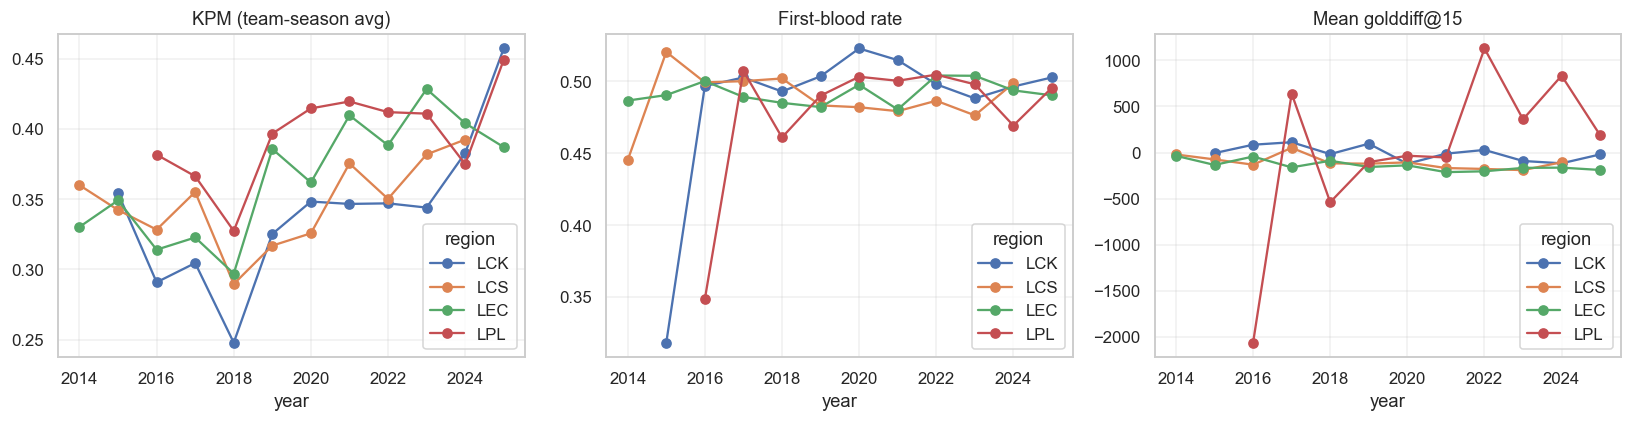

In [20]:
main = ["LPL", "LCK", "LCS", "LEC"]
yearly = (
    filt[filt["region"].isin(main)]
    .groupby(["year", "region"])[["kpm", "fb_rate", "golddiff15_avg"]]
    .mean()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, metric, title in zip(
    axes,
    ["kpm", "fb_rate", "golddiff15_avg"],
    ["KPM (team-season avg)", "First-blood rate", "Mean golddiff@15"],
    strict=False,
):
    yearly[metric].unstack("region").plot(ax=ax, marker="o")
    ax.set_title(title)
    ax.set_xlabel("year")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Real teams


In [ ]:
# 2024 LPL 内部按 KPM 排序，看 top/bottom 是否符合直觉
sample = filt.query("year == 2024 and region == 'LPL'").sort_values("kpm", ascending=False)
print("--- LPL 2024 by KPM ---")
print(sample[["teamname", "games", "kpm", "fb_rate", "golddiff15_avg"]].to_string(index=False))


--- LPL 2024 by KPM ---
           teamname  games      kpm  fb_rate  golddiff15_avg
    Anyone's Legend     86 0.443826 0.546512             NaN
    FunPlus Phoenix     86 0.432922 0.534884             NaN
 ThunderTalk Gaming     74 0.399250 0.445946             NaN
       Weibo Gaming    131 0.393540 0.473282          833.25
    Invictus Gaming     84 0.390090 0.547619             NaN
          Oh My God     75 0.388796 0.400000             NaN
         LGD Gaming     82 0.361691 0.390244             NaN
      EDward Gaming     69 0.333138 0.507246             NaN
        Ultra Prime     74 0.332147 0.445946             NaN
            Team WE     76 0.328039 0.407895             NaN
Royal Never Give Up     67 0.321612 0.462687             NaN


### Early-Game Dominance

CSD@10, golddiff@10.


### Vision Control

Vision score, wards placed/killed.


### Objective Focus

Dragon rate, baron rate, herald rate.


### Game Length as a Proxy for Macro Style


## 5. Regional Style Comparison


### Head-to-Head Comparison

Major regions: LPL, LCK, LCS, LEC, others.


### Per-Metric Breakdown with Visualizations


### Statistical Testing

ANOVA / Kruskal-Wallis to confirm differences are significant.


### Summary: Regional "Fingerprints"


## 6. Patch as a Shaping Force


### Patch Changes vs. Match Tempo


### Did Patches Narrow or Widen Regional Style Gaps?


### Case Study

One or two specific patches with notable meta impact.


## 7. Conclusion


### Key Findings


### Limitations

Data gaps, roster changes, international tournaments not separated.


### Possible Extensions
